In [3]:
import pandas as pd
import numpy as np

FILE_1 = "data_refined.csv"
FILE_2 = "insurance_refined.csv"

df_1 = pd.read_csv(FILE_1)
df_2 = pd.read_csv(FILE_2)

print(df_1.head(2))
print(df_2.head(2))

from sklearn.model_selection import train_test_split

bc_train, bc_valid_test = train_test_split(df_1, test_size=0.2, random_state=0)
bc_valid, bc_test = train_test_split(bc_valid_test, test_size=0.5, random_state=0)

ins_train, ins_valid_test = train_test_split(df_2, test_size=0.2, random_state=0)
ins_valid, ins_test = train_test_split(ins_valid_test, test_size=0.5, random_state=0)


   radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0     1.097064     -2.073335        1.269934   0.984375         1.568466   
1     1.829821     -0.353632        1.685955   1.908708        -0.826962   

   compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
0          3.283515        2.652874             2.532475       2.217515   
1         -0.487072       -0.023846             0.548144       0.001392   

   fractal_dimension_mean  ...  texture_worst  perimeter_worst  area_worst  \
0                2.255747  ...      -1.359293         2.303601    2.001237   
1               -0.868652  ...      -0.369203         1.535126    1.890489   

   smoothness_worst  compactness_worst  concavity_worst  concave points_worst  \
0          1.307686           2.616665         2.109526              2.296076   
1         -0.375612          -0.430444        -0.146749              1.087084   

   symmetry_worst  fractal_dimension_worst  diagnosis  
0        2

In [9]:
from sklearn.neural_network import MLPClassifier

y_train = bc_train['diagnosis']
X_train = bc_train.drop('diagnosis', axis=1)
y_valid = bc_valid['diagnosis']
X_valid = bc_valid.drop('diagnosis', axis=1)

ann = MLPClassifier(hidden_layer_sizes=(100,), alpha=0.0001, max_iter=400, random_state=0, early_stopping=False)
ann.fit(X_train, y_train)
score = ann.score(X_valid, y_valid)
print("Validation accuracy score: ",score)



Validation accuracy score:  0.9824561403508771


Text(0.5, 1.0, 'SKLearn MLPClassifier Confusion Matrix')

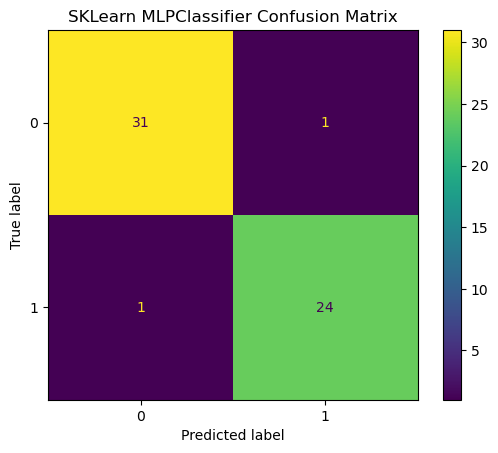

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_test = bc_test['diagnosis']
X_test = bc_test.drop('diagnosis', axis=1)

y_pred = ann.predict(X_test)
fig = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred))
fig.plot()
fig.ax_.set_title("SKLearn MLPClassifier Confusion Matrix")

In [11]:
from keras.models import Sequential
ann = Sequential()

from keras.layers import Dense
ann.add(Dense(units=100, activation='relu', kernel_initializer='uniform'))
ann.add(Dense(units=1, activation='sigmoid', kernel_initializer='uniform'))

ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
ann.fit(X_train, y_train, batch_size=10, epochs=100)


Epoch 1/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9343 - loss: 0.5832 
Epoch 2/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9616 - loss: 0.1900
Epoch 3/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9842 - loss: 0.0967
Epoch 4/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9843 - loss: 0.0816
Epoch 5/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9868 - loss: 0.0864
Epoch 6/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9864 - loss: 0.0769
Epoch 7/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9800 - loss: 0.0718
Epoch 8/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9942 - loss: 0.0426
Epoch 9/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9900 - loss: 0.0525
Epoch 10/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9874 - loss: 0.0594
Epoch 11/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9962 - loss: 0.0324
Epoch 12/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy

In [13]:
from sklearn.metrics import accuracy_score
score = accuracy_score(y_valid, ann.predict(X_valid)>0.5)
print("Validation accuracy score: ",score)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Validation accuracy score:  0.9824561403508771


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


Text(0.5, 1.0, 'SKLearn MLPClassifier Confusion Matrix')

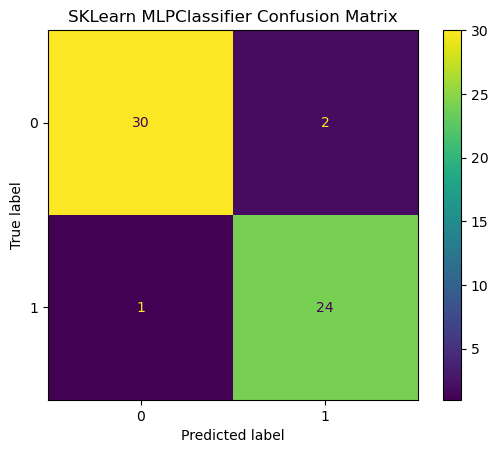

In [14]:
y_pred = ann.predict(X_test)>0.5
fig = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred))
fig.plot()
fig.ax_.set_title("SKLearn MLPClassifier Confusion Matrix")

In [19]:
from sklearn.neural_network import MLPRegressor

target='charges'
y_train = ins_train[target]
X_train = ins_train.drop(target, axis=1)
y_valid = ins_valid[target]
X_valid = ins_valid.drop(target, axis=1)
y_test = ins_test[target]
X_test = ins_test.drop(target, axis=1)


ann = MLPRegressor(hidden_layer_sizes=(100,100,), activation='relu', solver='adam', batch_size=10, max_iter=1000, random_state=0)
ann.fit(X_train, y_train)

print("Validation R2 score: ", ann.score(X_valid, y_valid))
print("Testing R2 score: ", ann.score(X_test, y_test))

Validation R2 score:  0.9174365550113487
Testing R2 score:  0.8244317743022904


In [25]:
ann = Sequential()
ann.add(Dense(units=100, activation='relu'))
ann.add(Dense(units=100, activation='relu'))
ann.add(Dense(units=1, activation='relu')) #regressor output layer

ann.compile(optimizer='adam', loss='mean_squared_error', metrics=['accuracy'])
ann.fit(X_train, y_train, batch_size=10, epochs=1000, verbose=0)

In [ ]:
from sklearn.metrics import r2_score

print("Validation R2 score: ", r2_score(y_valid, ann.predict(X_valid)))
print("Validation R2 score: ", r2_score(y_test, ann.predict(X_test)))

# The regression scores are generally very good.  The Keras test score was a bit low at 69%, but it's likely due
# to randomized test selection

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Validation R2 score:  0.8365622639608807
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Validation R2 score:  0.6894957648432058
